# **Exploratory Data Analysis: Univariate**
**Decodelabs Internship | Week 2 | Task 3 (Part 1)**

---
Here, I examined each feature individually, its distribution, range, outliers,
and basic statistics. This gives me a complete picture of the dataset
before I look at relationships between features.


In [1]:
import sys, os
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from configs.config import (
    RAW_FILE, IDS_MAP_FILE, INTERIM_FILE, PROCESSED_FILE,
    TRAIN_FILE, VAL_FILE, TEST_FILE,
    FIGURES_DIR, TABLES_DIR, PAPER_FIG_DIR, PAPER_TAB_DIR,
    RANDOM_SEED, TARGET_COL, PATIENT_ID_COL, MEDICATION_COLS,
    AGE_ORDER, icd9_to_category, COLORS, ensure_dirs
)
from src.plot_utils import set_plot_style, save_figure, save_table
ensure_dirs()
set_plot_style()
print("Config loaded. Seed:", RANDOM_SEED)

Config loaded. Seed: 42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(PROCESSED_FILE)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Separate features by type for targeted analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove target and patient ID
numeric_features = [c for c in numeric_cols if c not in [TARGET_COL, PATIENT_ID_COL]]
print(f"Numeric feature columns: {len(numeric_features)}")

Loaded: 69,987 rows × 54 columns
Numeric feature columns: 48


## Class balance visualisation

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\04_class_balance.png


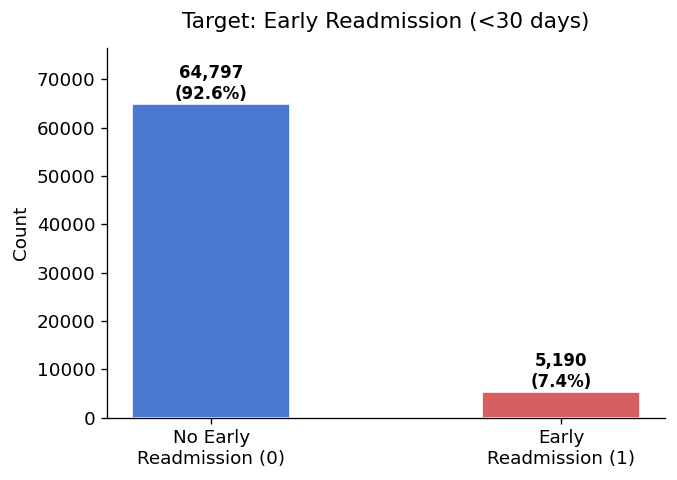

Class 0 (no early readmit): 64,797 (92.6%)
Class 1 (early readmit)   : 5,190 (7.4%)

Class imbalance ratio: 1 positive per 12.5 negatives

This imbalance (~11% positive rate) means:
  - A naive model predicting 0 always gets ~89% accuracy but 0% recall for class 1.
  - I must use class_weight='balanced' or SMOTE in modelling.
  - I must use ROC-AUC and PR-AUC as primary metrics, not accuracy.


In [3]:
from src.plot_utils import plot_class_balance

fig = plot_class_balance(df[TARGET_COL], title="Target: Early Readmission (<30 days)")
save_figure(fig, "04_class_balance.png", FIGURES_DIR)
plt.show()

counts = df[TARGET_COL].value_counts().sort_index()
print(f"Class 0 (no early readmit): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (early readmit)   : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print()
print("Class imbalance ratio: 1 positive per",
      f"{counts[0]/counts[1]:.1f} negatives")
print()
print("This imbalance (~11% positive rate) means:")
print("  - A naive model predicting 0 always gets ~89% accuracy but 0% recall for class 1.")
print("  - I must use class_weight='balanced' or SMOTE in modelling.")
print("  - I must use ROC-AUC and PR-AUC as primary metrics, not accuracy.")

## Descriptive statistics for all numeric features

In [4]:
print("=== Descriptive Statistics ===")
desc = df[numeric_features].describe().round(2)
print(desc.T.to_string())
save_table(desc.T, "04_descriptive_statistics.csv", TABLES_DIR)

=== Descriptive Statistics ===
                            count   mean    std  min   25%   50%   75%    max
admission_type_id         69987.0   2.09   1.49  1.0   1.0   1.0   3.0    8.0
discharge_disposition_id  69987.0   3.38   5.09  1.0   1.0   1.0   3.0   28.0
admission_source_id       69987.0   5.66   4.15  1.0   1.0   7.0   7.0   25.0
time_in_hospital          69987.0   4.29   2.94  1.0   2.0   3.0   6.0   14.0
num_lab_procedures        69987.0  43.00  19.79  1.0  31.0  44.0  57.0  132.0
num_procedures            69987.0   1.40   1.74  0.0   0.0   1.0   2.0    6.0
num_medications           69987.0  15.75   8.25  1.0  10.0  14.0  20.0   81.0
number_outpatient         69987.0   0.30   1.11  0.0   0.0   0.0   0.0   42.0
number_emergency          69987.0   0.12   0.63  0.0   0.0   0.0   0.0   54.0
number_inpatient          69987.0   0.33   0.82  0.0   0.0   0.0   0.0   17.0
number_diagnoses          69987.0   7.27   1.99  1.0   6.0   8.0   9.0   16.0
metformin                 69987.0

'c:\\Users\\Peter\\Documents\\EXTRA-CURRICULA\\Internship\\Decodelab\\diabetes_readmission\\reports\\tables\\04_descriptive_statistics.csv'

## Distributions of clinical numeric features

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\04_clinical_distributions.png


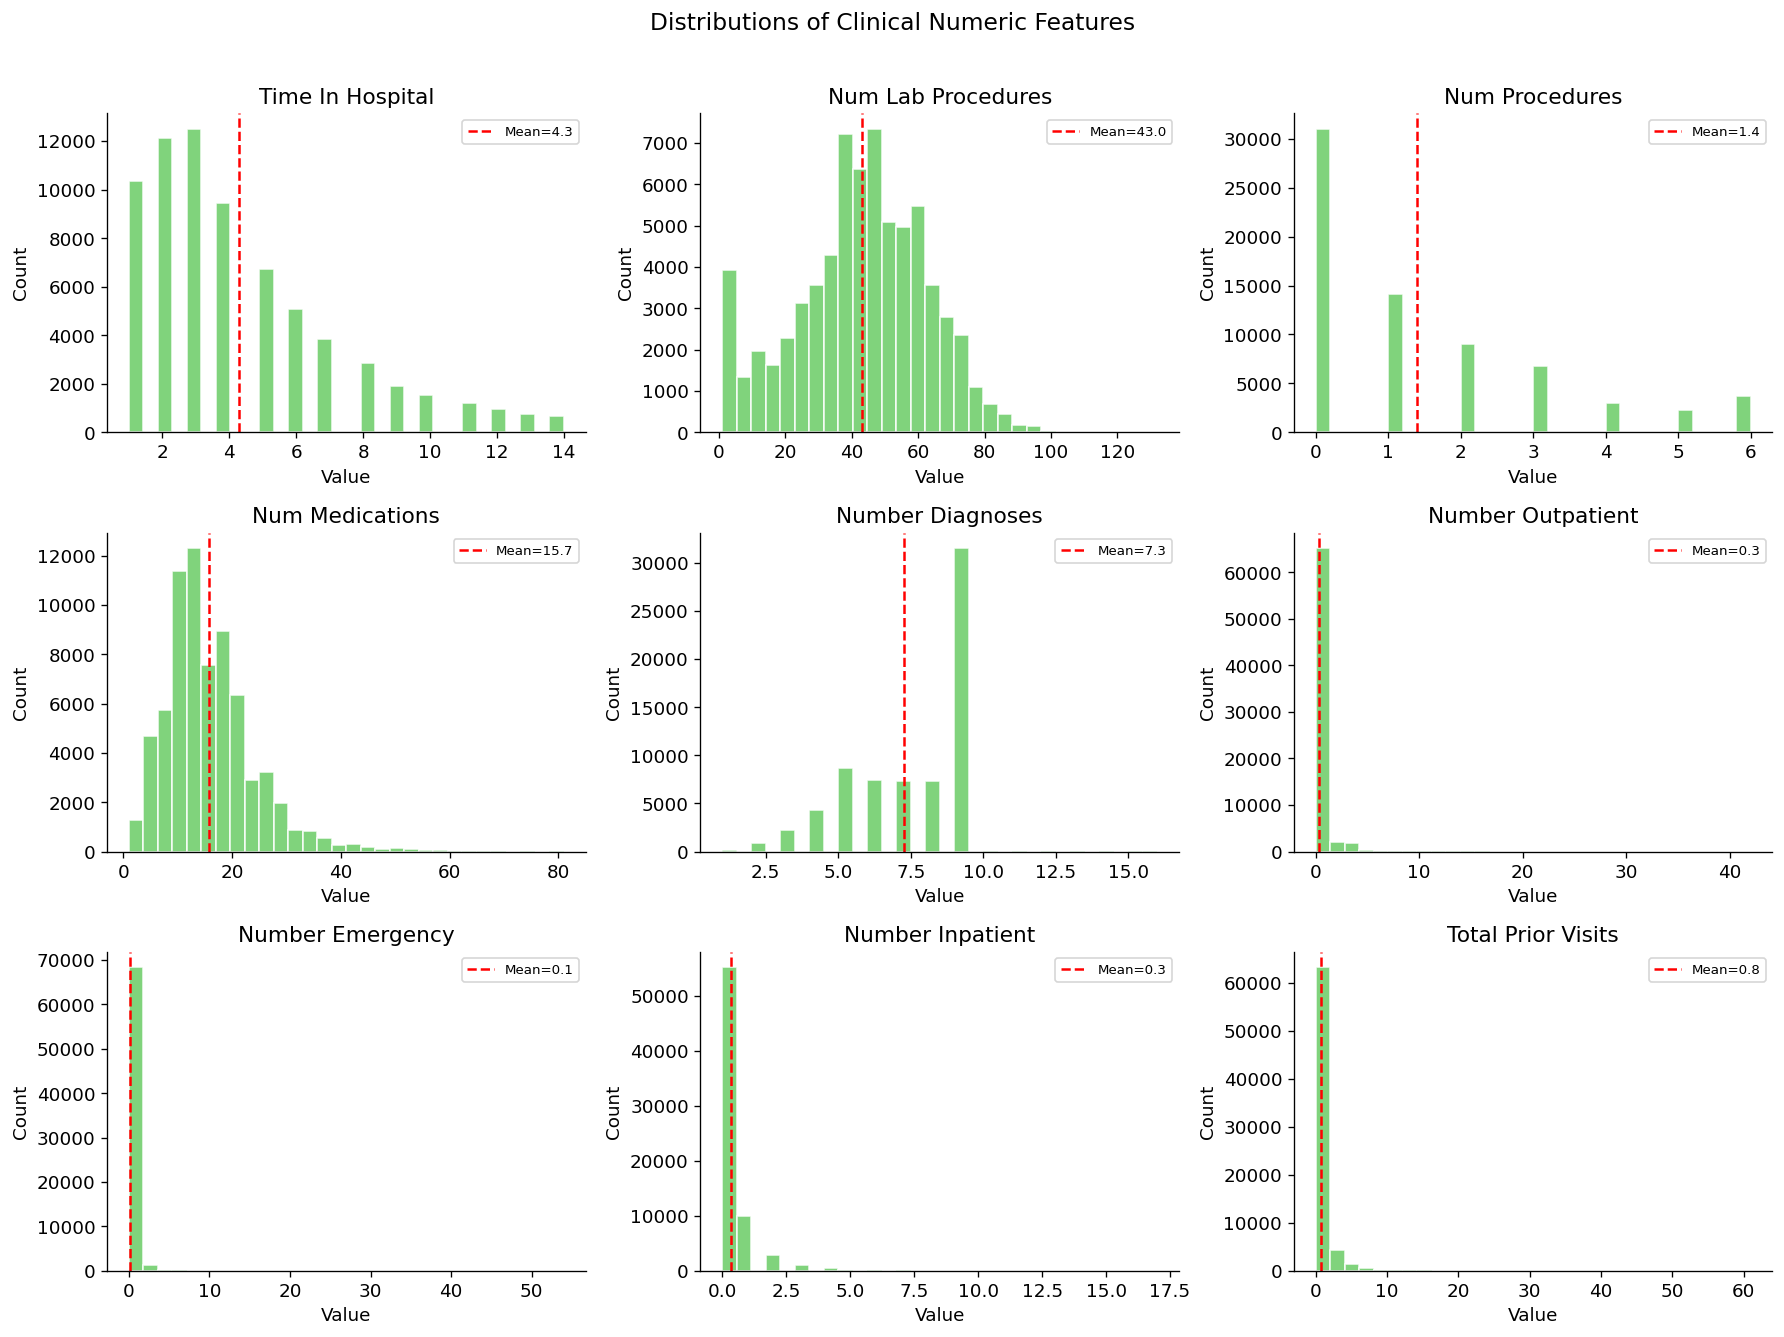

In [5]:
# I plot histograms for the continuous clinical features.
clinical_num = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                "num_medications", "number_diagnoses",
                "number_outpatient", "number_emergency", "number_inpatient",
                "total_prior_visits"]

# Filter to only columns that exist in df
clinical_num = [c for c in clinical_num if c in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(clinical_num[:9]):
    ax = axes[i]
    ax.hist(df[col], bins=30, color=COLORS["neutral"], edgecolor="white", alpha=0.85)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5,
               label=f"Mean={mean_val:.1f}")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Distributions of Clinical Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
save_figure(fig, "04_clinical_distributions.png", FIGURES_DIR)
plt.show()

## Outlier detection

In [6]:
print("=== Outlier Detection (IQR Method) ===")
outlier_summary = []

for col in clinical_num:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    pct   = n_out / len(df) * 100
    outlier_summary.append({
        "Feature": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "Lower bound": round(lb,1), "Upper bound": round(ub,1),
        "N outliers": n_out, "% outliers": round(pct,2)
    })

out_df = pd.DataFrame(outlier_summary).set_index("Feature")
print(out_df[["N outliers","% outliers","Lower bound","Upper bound"]].to_string())
save_table(out_df, "04_outlier_summary.csv", TABLES_DIR)
print()
print("I will not remove these outliers — most represent real extreme clinical values.")
print("E.g. a patient with 100+ lab procedures is unusual but real.")

=== Outlier Detection (IQR Method) ===
                    N outliers  % outliers  Lower bound  Upper bound
Feature                                                             
time_in_hospital          1430        2.04         -4.0         12.0
num_lab_procedures         101        0.14         -8.0         96.0
num_procedures            3725        5.32         -3.0          5.0
num_medications           1882        2.69         -5.0         35.0
number_diagnoses           231        0.33          1.5         13.5
number_outpatient         9762       13.95          0.0          0.0
number_emergency          5781        8.26          0.0          0.0
number_inpatient         14764       21.10          0.0          0.0
total_prior_visits        6623        9.46         -1.5          2.5
  Table  saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\tables\04_outlier_summary.csv

I will not remove these outliers — most represent real extreme 

## Categorical feature distributions

In [7]:
# I visualise the key categorical features: diagnosis categories,
# race, admission type, discharge disposition.

cat_cols_to_plot = [c for c in ["diag_1_cat", "race", "admission_type_id",
                                  "discharge_disposition_id"] if c in df.columns]

for col in cat_cols_to_plot:
    vc = df[col].value_counts()
    print(f"=== {col} ===")
    print(vc.to_string())
    print()

=== diag_1_cat ===
diag_1_cat
Circulatory         21119
Other               16752
Respiratory          9468
Digestive            6534
Injury               4817
Musculoskeletal      3950
Genitourinary        3548
Neoplasm             2514
Other / External     1085
Diabetes              200

=== race ===
race
Caucasian          52328
AfricanAmerican    12637
Hispanic            1499
Other               1148
Asian                492

=== admission_type_id ===
admission_type_id
1    35779
3    13787
2    12811
6     4334
5     2956
8      295
7       16
4        9

=== discharge_disposition_id ===
discharge_disposition_id
1     44043
3      9116
6      8422
18     2493
2      1510
22     1365
5       881
25      648
4       562
7       409
23      278
28       82
8        68
15       42
24       31
9        11
17       10
10        6
16        5
27        3
12        2



  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\04_diagnosis_categories.png


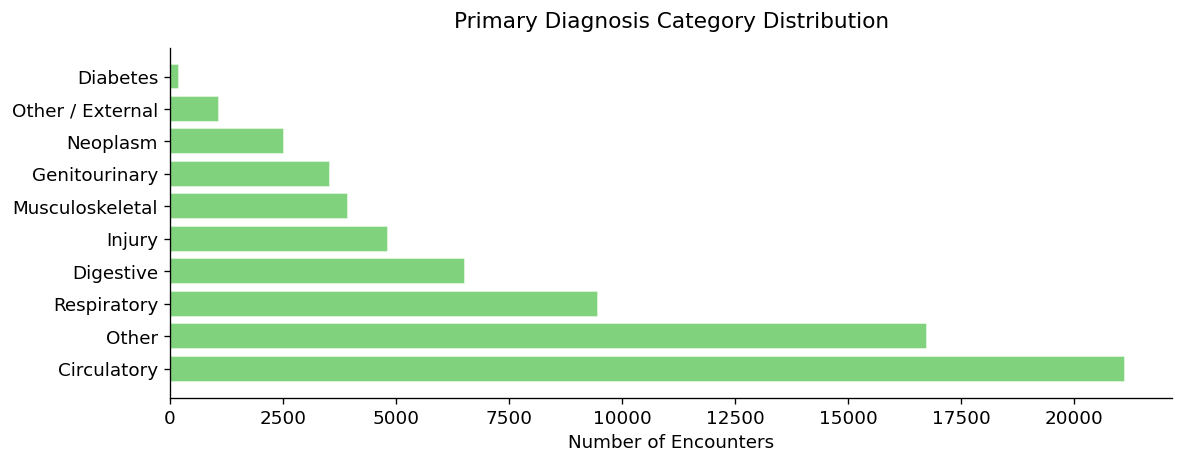

In [8]:
# Bar chart of primary diagnosis categories
if "diag_1_cat" in df.columns:
    diag_counts = df["diag_1_cat"].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(diag_counts.index, diag_counts.values,
                   color=COLORS["neutral"], alpha=0.85, edgecolor="white")
    ax.set_xlabel("Number of Encounters")
    ax.set_title("Primary Diagnosis Category Distribution", pad=12)
    plt.tight_layout()
    save_figure(fig, "04_diagnosis_categories.png", FIGURES_DIR)
    plt.show()

## Medication feature distributions

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\04_medication_distributions.png


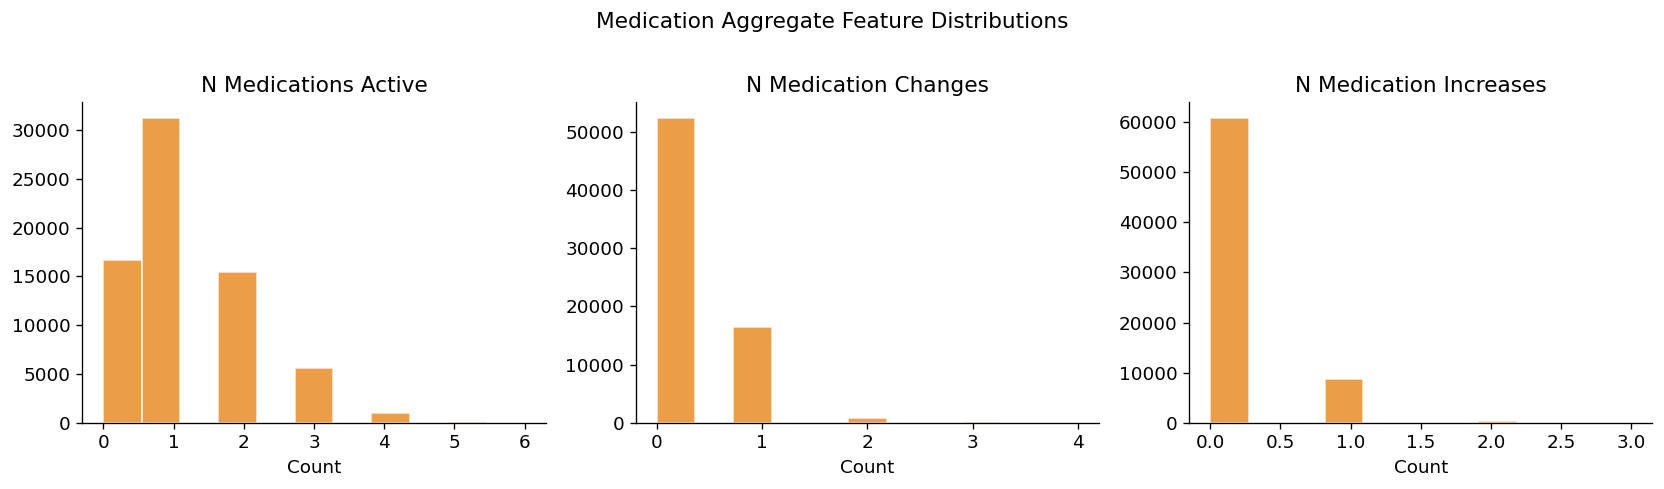

In [9]:
# Summary of medication aggregate features
med_agg_cols = ["n_medications_active", "n_medication_changes",
                "n_medication_increases"]
med_agg_cols = [c for c in med_agg_cols if c in df.columns]

fig, axes = plt.subplots(1, len(med_agg_cols), figsize=(14, 4))
if len(med_agg_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, med_agg_cols):
    ax.hist(df[col], bins=max(df[col].max(), 10)+1,
            color=COLORS["highlight"], alpha=0.8, edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Count")

fig.suptitle("Medication Aggregate Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
save_figure(fig, "04_medication_distributions.png", FIGURES_DIR)
plt.show()

## Skewness check

In [10]:
# Highly skewed features may need log-transformation for linear models.
# Tree-based models (RF, XGBoost) are invariant to monotonic transformations.

skewness = df[clinical_num].skew().sort_values(ascending=False).round(3)
print("=== Feature Skewness ===")
print(skewness.to_string())
print()
print("Skewness > 1 or < -1 is considered high.")
high_skew = skewness[abs(skewness) > 1]
print(f"Highly skewed features ({len(high_skew)}):")
print(high_skew.to_string())
print()
print("Note: I will apply log1p transformation to highly skewed features")
print("before training linear models. Tree models don't need this.")

=== Feature Skewness ===
number_emergency      24.556
number_outpatient      8.887
total_prior_visits     6.043
number_inpatient       4.119
num_medications        1.399
num_procedures         1.250
time_in_hospital       1.178
num_lab_procedures    -0.226
number_diagnoses      -0.759

Skewness > 1 or < -1 is considered high.
Highly skewed features (7):
number_emergency      24.556
number_outpatient      8.887
total_prior_visits     6.043
number_inpatient       4.119
num_medications        1.399
num_procedures         1.250
time_in_hospital       1.178

Note: I will apply log1p transformation to highly skewed features
before training linear models. Tree models don't need this.
